# 4a. Logistic Regression (Baseline)

**Project:** Predicting colorectal cancer screening non-compliance to guide targeted outreach
**Part of:** the modelling stage, split one notebook per model (`4a`-`4d`) so each model's fit,
results, and interpretation can be read, run, and re-run independently. All four write into the
same shared model registry (`data/processed/modelling/model_registry_manifest.csv`); the
cross-model comparison lives in `5 Evaluation.ipynb`, which reads that shared manifest rather than
refitting anything itself. (next: `4b (Random Forest)`)

**Inputs:** `crc_analytic_dataset.csv` (Data Preparation output), the split/technique artifacts
validated in `3 Data Processing.ipynb`, and the shared preprocessing components in
`pipeline_components.py`.

This notebook covers the interpretable baseline the proposal requires -- fit on M1/M2/M3 with an odds-ratio interpretation for M3. Every model notebook follows the same three-part structure --
**Model** (what's fit and how), **Results** (held-out test performance), **Analysis of factors**
(what's driving the predictions) -- so the four are easy to compare despite living in separate
files.

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROCESSED_DIR / "modelling"
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ANALYTIC_PATH = PROCESSED_DIR / "crc_analytic_dataset.csv"
SPLIT_PATH = MODEL_DIR / "train_calibration_test_split.csv"
for p in [ANALYTIC_PATH, SPLIT_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"{p} not found. Run '3 Data Processing.ipynb' first.")

df = pd.read_csv(
    ANALYTIC_PATH,
    dtype={"respondent_id": "string", "state_fips": "string"},
    low_memory=False,
)
split_assignment = pd.read_csv(SPLIT_PATH, dtype={"respondent_id": "string"})
df = df.merge(split_assignment, on="respondent_id", validate="one_to_one")

assert df["split"].isna().sum() == 0
print("Loaded:", ANALYTIC_PATH)
print(df["split"].value_counts())

Loaded: ..\data\processed\crc_analytic_dataset.csv
split
train          136588
test            45530
calibration     45529
Name: count, dtype: int64


In [14]:
import sys

sys.path.insert(0, str(Path.cwd()))
from pipeline_components import (
    RANDOM_SEED, M1_FEATURES, M2_FEATURES, M3_FEATURES,
    ORDINAL_FEATURES, NOMINAL_FEATURES, ORDINAL_CATEGORY_ORDER,
    OrdinalRankWithMissingFlag, ordinal_subset, nominal_subset,
    build_logreg_pipeline, compute_classification_metrics, make_model_registry,
)

np.random.seed(RANDOM_SEED)
assert len(M1_FEATURES) == 8 and len(M2_FEATURES) == 12 and len(M3_FEATURES) == 17

X_train = df.loc[df["split"] == "train", M3_FEATURES]
y_train = df.loc[df["split"] == "train", "crc_noncompliant"]
X_cal = df.loc[df["split"] == "calibration", M3_FEATURES]
y_cal = df.loc[df["split"] == "calibration", "crc_noncompliant"]
X_test = df.loc[df["split"] == "test", M3_FEATURES]
y_test = df.loc[df["split"] == "test", "crc_noncompliant"]

for name, Xs, ys in [("train", X_train, y_train), ("calibration", X_cal, y_cal), ("test", X_test, y_test)]:
    print(f"{name:12s} n={len(Xs):>7,}   non-compliance rate={ys.mean():.4f}")

print("\nPipeline builder ready: build_logreg_pipeline(features)")

train        n=136,588   non-compliance rate=0.2648
calibration  n= 45,529   non-compliance rate=0.2648
test         n= 45,530   non-compliance rate=0.2648

Pipeline builders ready: build_logreg_pipeline(features) [used below], build_gb_pipeline(features) [ready for the next model]


In [5]:
MODELS_DIR = MODEL_DIR / "models"
MANIFEST_PATH = MODEL_DIR / "model_registry_manifest.csv"
MODEL_REGISTRY, register_model, load_registry = make_model_registry(MODELS_DIR, MANIFEST_PATH)

print("Model registry ready. Models will be saved under:", MODELS_DIR)
print("Comparison manifest (shared across 4a-4d) will be written to:", MANIFEST_PATH)

Model registry ready. Models will be saved under: ../data/processed/modelling/models
Comparison manifest (shared across 4a-4d) will be written to: ../data/processed/modelling/model_registry_manifest.csv

## Model

Fit on each of M1/M2/M3, class-weighted via `sample_weight` for the 26.5% imbalance rather than oversampling (oversampling to 50/50 would distort the probabilities this project later needs to calibrate, and SMOTE-style interpolation doesn't make sense for one-hot categorical features). This is the interpretable baseline the proposal asks for in step (d).

In [7]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt

w_train = compute_sample_weight("balanced", y_train)

In [8]:
logreg_rows = []
logreg_test_probas = {}
for domain_name, features in [("M1", M1_FEATURES), ("M2", M2_FEATURES), ("M3", M3_FEATURES)]:
    pipe = build_logreg_pipeline(features)
    pipe.fit(X_train[features], y_train, model__sample_weight=w_train)
    proba = pipe.predict_proba(X_test[features])[:, 1]
    metrics = compute_classification_metrics(y_test, proba)
    logreg_rows.append({"Model": domain_name, "N predictors": len(features), **metrics})
    logreg_test_probas[domain_name] = proba
    register_model(
        name=f"logreg_{domain_name}", pipeline=pipe, metrics=metrics, features=features,
        model_type="Logistic Regression (class-weighted)",
        notes="Baseline; class-weighted for imbalance, not for interpretation -- see Analysis of factors.",
    )

logreg_table = pd.DataFrame(logreg_rows)
logreg_table.to_csv(MODEL_DIR / "baseline_logreg_results.csv", index=False)
logreg_table.round(3)

  Model  N predictors  AUROC  AUPRC  Precision  Sensitivity     F1  Accuracy
0    M1             8  0.710  0.483      0.408        0.660  0.504     0.656
1    M2            12  0.753  0.581      0.469        0.642  0.542     0.712
2    M3            17  0.755  0.583      0.473        0.645  0.546     0.716

## Results

Access again does most of the work -- the jump from M1 to M2 is where AUROC and AUPRC move; M3's health-status predictors add comparatively little on top, consistent with the access-is-the-modifiable-signal finding running through this whole project.

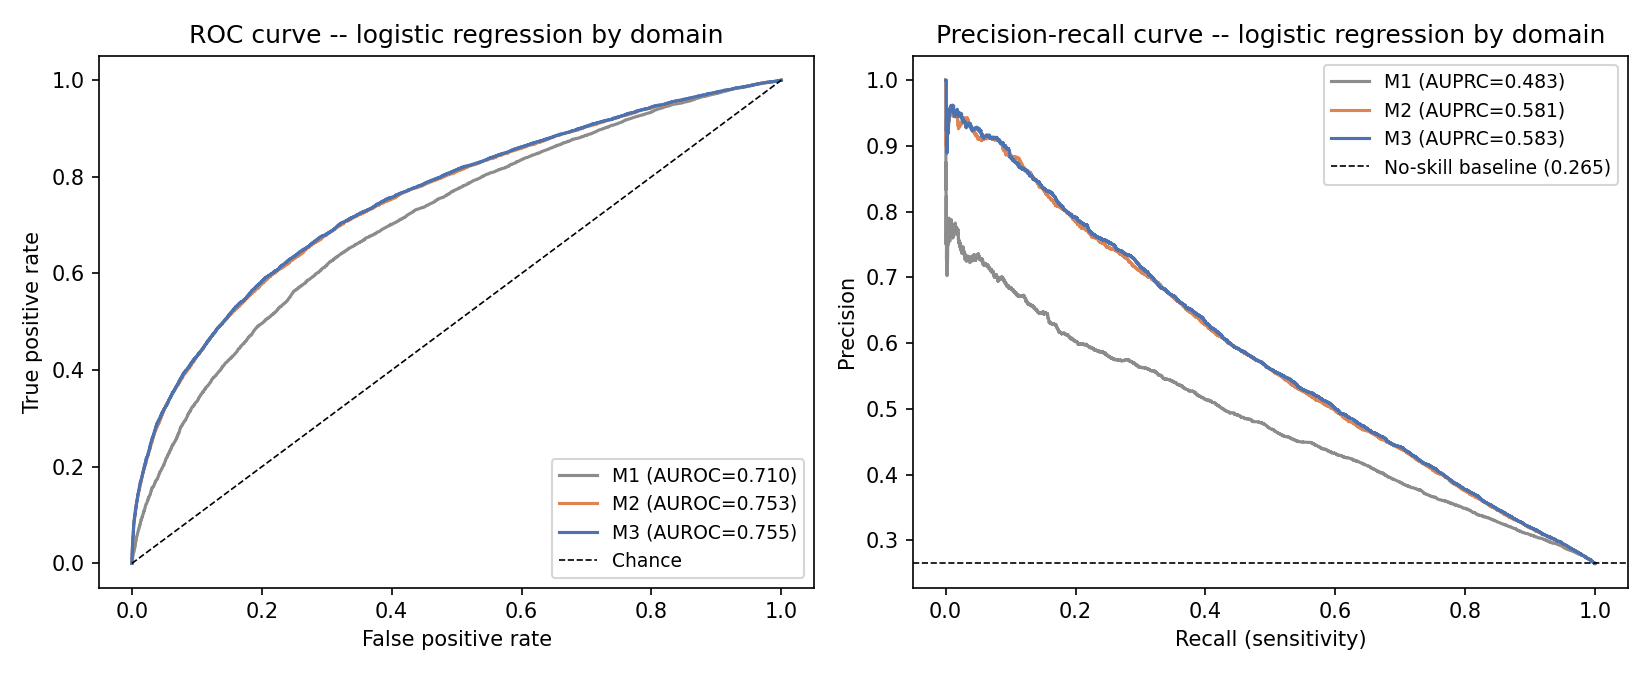

In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = {"M1": "#8C8C8C", "M2": "#DD8452", "M3": "#4C72B0"}

for domain_name in ["M1", "M2", "M3"]:
    proba = logreg_test_probas[domain_name]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auroc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=colors[domain_name], label=f"{domain_name} (AUROC={auroc:.3f})")

    precision, recall, _ = precision_recall_curve(y_test, proba)
    auprc = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, color=colors[domain_name], label=f"{domain_name} (AUPRC={auprc:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=0.8, label="Chance")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve -- logistic regression by domain")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].axhline(y_test.mean(), linestyle="--", color="black", linewidth=0.8,
                label=f"No-skill baseline ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall (sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve -- logistic regression by domain")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig11_logreg_roc_pr_curves.png", dpi=150)
plt.show()

## Analysis of factors

Proposal step (f) asks to rank predictors using "absolute coefficients" for the interpretable
baseline. Two things need to be handled carefully to make that ranking meaningful, both different
from how the Results-section model above was fit:

**A separate, unweighted refit.** The Results section above uses `sample_weight` to improve
ranking and sensitivity for a targeting use case -- a machine-learning choice about the
classifier's decision behaviour. It is not a correction for biased sampling: the 26.5%
non-compliance rate is the real observed rate, not an artefact of how the data was collected.
Reusing those coefficients for odds ratios would describe an artificially reweighted population
that doesn't exist. The interpretation below refits an **unweighted** logistic regression on the
same M3 features, specifically for this table -- it is not used for ranking or registered as a
comparison model, only for interpretation.

**Explicit, sensible reference categories.** `OneHotEncoder(drop="first")` drops whichever
category sorts first alphabetically by default -- for `race_ethnicity` that would silently make
"Black only, non-Hispanic" the reference, and for `urban_rural` it would make "Not reported" the
reference, neither of which is a sensible baseline to interpret against. Each nominal feature's
reference level is set explicitly to its most frequent category instead.

**What this is not:** per the proposal's own framing, "the purpose is prediction for targeting
rather than causal explanation." Odds ratios below describe association strength and direction in
this sample, in line with proposal step (f)'s predictor-ranking request -- they are not causal
effect estimates.

In [18]:
from sklearn.preprocessing import OneHotEncoder

NOMINAL_REFERENCE = {
    col: X_train[col].value_counts().idxmax() for col in nominal_subset(M3_FEATURES)
}
print("Reference (baseline) category used for each nominal predictor:")
for col, ref in NOMINAL_REFERENCE.items():
    print(f"  {col:20s} -> {ref}")

Reference (baseline) category used for each nominal predictor:
  sex                  -> Female
  race_ethnicity       -> White only, non-Hispanic
  employment_status    -> Employed for wages
  marital_status       -> Married
  urban_rural          -> Urban
  insurance_status     -> Insured
  personal_doctor      -> Has personal doctor
  cost_barrier         -> No
  checkup_recency      -> Within past year
  diabetes_status      -> No diabetes
  heart_disease        -> CHD or MI not reported
  smoking_status       -> Never smoked
  bmi_category         -> Obese


In [19]:
import statsmodels.api as sm

def ordinal_rank_flag(X, cols):
    out = {}
    for col in cols:
        rank_map = {cat: rank for rank, cat in enumerate(ORDINAL_CATEGORY_ORDER[col])}
        ranks = X[col].map(rank_map)
        out[f"{col}__rank"] = ranks.fillna(-1).astype(float)
        out[f"{col}__not_reported"] = ranks.isna().astype(float)
    return pd.DataFrame(out, index=X.index)

nominal_cols = nominal_subset(M3_FEATURES)
ordinal_cols = ordinal_subset(M3_FEATURES)

explicit_categories = [
    [NOMINAL_REFERENCE[col]] + sorted(c for c in X_train[col].unique() if c != NOMINAL_REFERENCE[col])
    for col in nominal_cols
]
ohe_interpret = OneHotEncoder(drop="first", categories=explicit_categories, handle_unknown="ignore")
ohe_interpret.fit(X_train[nominal_cols])
nominal_names = ohe_interpret.get_feature_names_out(nominal_cols)

X_train_ordinal = ordinal_rank_flag(X_train, ordinal_cols)
X_train_nominal = pd.DataFrame(
    ohe_interpret.transform(X_train[nominal_cols]).toarray(), columns=nominal_names, index=X_train.index
)
design_matrix = pd.concat([X_train_ordinal, X_train_nominal], axis=1)
design_matrix_with_const = sm.add_constant(design_matrix.astype(float))

interpretation_model = sm.Logit(y_train.values, design_matrix_with_const.values)
interpretation_result = interpretation_model.fit(disp=0, maxiter=100)
print("Converged:", interpretation_result.mle_retvals["converged"])
print(f"McFadden's pseudo R-squared: {interpretation_result.prsquared:.3f}")

Converged: True
McFadden's pseudo R-squared: 0.160


In [20]:
param_names = design_matrix_with_const.columns
params = pd.Series(interpretation_result.params, index=param_names).drop("const")
conf_int = interpretation_result.conf_int()
ci_low = pd.Series(conf_int[:, 0], index=param_names).drop("const")
ci_high = pd.Series(conf_int[:, 1], index=param_names).drop("const")
p_values = pd.Series(interpretation_result.pvalues, index=param_names).drop("const")

odds_ratio_table = pd.DataFrame({
    "odds_ratio": np.exp(params),
    "ci_low": np.exp(ci_low),
    "ci_high": np.exp(ci_high),
    "p_value": p_values,
}).sort_values("odds_ratio", ascending=False)
odds_ratio_table.to_csv(MODEL_DIR / "baseline_logreg_odds_ratios.csv")

print("Predictors most associated with HIGHER non-compliance odds:")
odds_ratio_table.head(8).round(4)

Predictors most associated with HIGHER non-compliance odds:


,odds_ratio,ci_low,ci_high,p_value
checkup_recency_5 or more years,8.2056,7.5107,8.9648,0.0000
checkup_recency_Never,5.8868,4.5855,7.5573,0.0000
checkup_recency_2 to < 5 years,3.5069,3.2662,3.7654,0.0000
checkup_recency_Not reported,2.4469,2.1277,2.8141,0.0000
personal_doctor_No personal doctor,2.1097,1.9997,2.2257,0.0000
checkup_recency_1 to < 2 years,1.9467,1.8572,2.0404,0.0000
insurance_status_Uninsured,1.6542,1.5357,1.7819,0.0000
cost_barrier_Not reported,1.5698,1.2576,1.9594,0.0001


In [21]:
print("Predictors most associated with LOWER non-compliance odds (protective):")
odds_ratio_table.tail(8).round(4)

Predictors most associated with LOWER non-compliance odds (protective):


,odds_ratio,ci_low,ci_high,p_value
education_level__rank,0.8421,0.8286,0.8559,0.0000
diabetes_status_Prediabetes or borderline diabetes,0.8379,0.7736,0.9074,0.0000
employment_status_Retired,0.8112,0.7784,0.8455,0.0000
education_level__not_reported,0.7948,0.6473,0.9758,0.0283
employment_status_Unable to work,0.7517,0.7117,0.7940,0.0000
age_group__rank,0.7324,0.7250,0.7400,0.0000
income_group__not_reported,0.6728,0.6319,0.7164,0.0000
age_group__not_reported,0.5440,0.4960,0.5967,0.0000


**Forest plot:** the 12 predictors most associated with higher odds and the 12 most associated with lower odds, with 95% confidence intervals. Log-scaled x-axis, dashed line at OR=1 (no association).

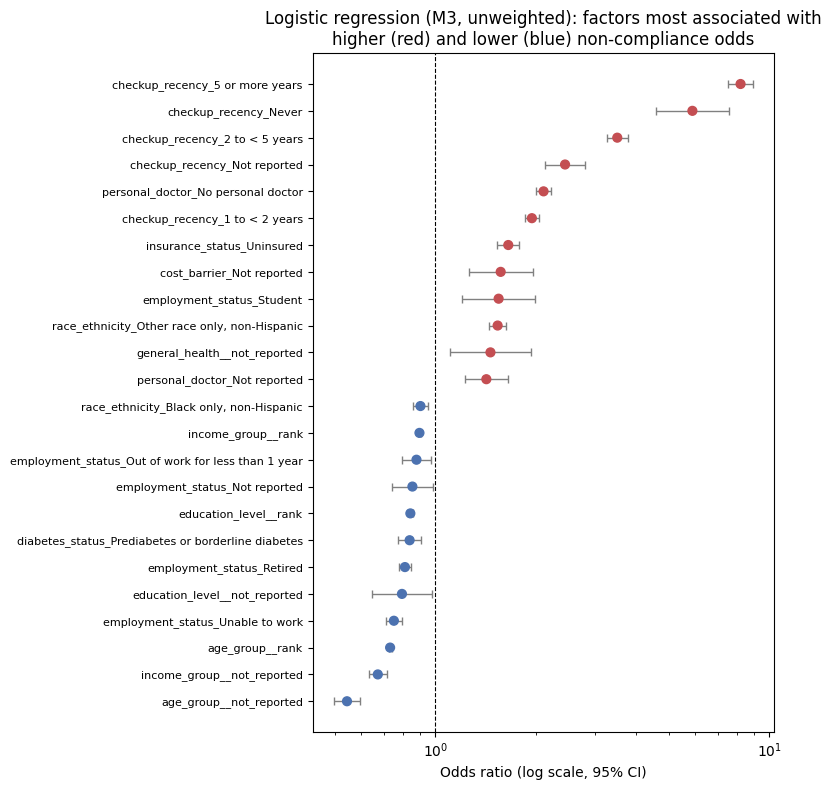

In [22]:
top_n = 12
plot_table = pd.concat([odds_ratio_table.head(top_n), odds_ratio_table.tail(top_n)]).sort_values("odds_ratio")

fig, ax = plt.subplots(figsize=(8, 8))
y_pos = np.arange(len(plot_table))
xerr_low = plot_table["odds_ratio"] - plot_table["ci_low"]
xerr_high = plot_table["ci_high"] - plot_table["odds_ratio"]

colors_fp = ["#4C72B0" if v < 1 else "#C44E52" for v in plot_table["odds_ratio"]]
ax.errorbar(
    plot_table["odds_ratio"], y_pos, xerr=[xerr_low, xerr_high],
    fmt="o", color="black", ecolor="gray", elinewidth=1, capsize=3, markersize=0,
)
ax.scatter(plot_table["odds_ratio"], y_pos, color=colors_fp, zorder=3, s=40)
ax.axvline(1, linestyle="--", color="black", linewidth=0.8)
ax.set_xscale("log")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_table.index, fontsize=8)
ax.set_xlabel("Odds ratio (log scale, 95% CI)")
ax.set_title("Logistic regression (M3, unweighted): factors most associated with\n"
             "higher (red) and lower (blue) non-compliance odds")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig12_logreg_odds_ratio_forest_plot.png", dpi=150)
plt.show()

**Reading the chart and table:** the strongest associations by far are healthcare-access
behaviours, not demographics -- `checkup_recency = 5 or more years` (OR 8.21 vs. the reference,
within the past year) and `checkup_recency = Never` (OR 5.89) dominate the top of the ranking,
followed by `checkup_recency = 2 to < 5 years` (OR 3.51), `personal_doctor = No personal doctor`
(OR 2.11) and `insurance_status = Uninsured` (OR 1.65). This matches the M1-to-M2 jump being where
predictive performance moved in the Results section, and matches the whole project's recurring
finding that access -- not demographic composition -- is the dominant, modifiable signal. At the
protective end, older age and being retired both lower the odds (age_group rank OR 0.73 per band;
retired OR 0.81 vs. employed), and the two "not reported" flags for age and income carry some of
the largest protective-looking coefficients (OR 0.54 and 0.67) -- a reminder that "Not reported"
is not a neutral placeholder here, it's its own pattern the model is picking up on, which is
exactly why the equity work later treats it as a visible group rather than folding it into a
reference category.

**On the p-values:** with n=136,588 training rows, standard errors are small enough that almost
every coefficient will read as statistically significant regardless of whether its effect size is
practically meaningful -- the p-value column is included for completeness (and because a
health-statistics audience will expect it), but the odds-ratio magnitude and its confidence
interval width are the more informative numbers to report at this sample size, not the p-value
alone.